In [ ]:
#Dataset
from torch.utils.data import Dataset, DataLoader
import os
import torchvision.transforms as transforms
import cv2

#download data here
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/2011_10_03_drive_0047/2011_10_03_drive_0047_sync.zip
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/2011_10_03_calib.zip
!jar xf 2011_10_03_drive_0047_sync.zip
!jar xf 2011_10_03_calib.zip

--2025-04-06 17:30:58--  https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/2011_10_03_drive_0047/2011_10_03_drive_0047_sync.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.138.37, 3.5.135.211, 52.219.168.11, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.138.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3103291675 (2.9G) [application/zip]
Saving to: ‘2011_10_03_drive_0047_sync.zip’

2011_10_03_drive_00 100%[===================>]   2.89G  32.6MB/s    in 93s     

2025-04-06 17:32:32 (31.7 MB/s) - ‘2011_10_03_drive_0047_sync.zip’ saved [3103291675/3103291675]

--2025-04-06 17:32:32--  https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/2011_10_03_calib.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 52.219.171.161, 52.219.169.125, 52.219.46.115, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|52.219.171.161|:443.

In [ ]:
import os
from glob import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (20, 10)

#import kitti utilities function
!wget https://github.com/itberrios/CV_tracking/raw/main/kitti_tracker/kitti_utils.py
from kitti_utils import *

--2025-04-06 17:32:44--  https://github.com/itberrios/CV_tracking/raw/main/kitti_tracker/kitti_utils.py
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/itberrios/CV_tracking/main/kitti_tracker/kitti_utils.py [following]
--2025-04-06 17:32:44--  https://raw.githubusercontent.com/itberrios/CV_tracking/main/kitti_tracker/kitti_utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9759 (9.5K) [text/plain]
Saving to: ‘kitti_utils.py’

kitti_utils.py      100%[===================>]   9.53K  --.-KB/s    in 0.001s  

2025-04-06 17:32:44 (16.9 MB/s) - ‘kitti_utils.py’ saved [9759/9759]



In [ ]:
with open('2011_10_03/calib_cam_to_cam.txt','r') as f:
    calib = f.readlines()

# get projection matrices (rectified left camera --> left camera (u,v,z))
P_rect2_cam2 = np.array([float(x) for x in calib[25].strip().split(' ')[1:]]).reshape((3,4))


# get rectified rotation matrices (left camera --> rectified left camera)
R_ref0_rect2 = np.array([float(x) for x in calib[24].strip().split(' ')[1:]]).reshape((3, 3,))

# add (0,0,0) translation and convert to homogeneous coordinates
R_ref0_rect2 = np.insert(R_ref0_rect2, 3, values=[0,0,0], axis=0)
R_ref0_rect2 = np.insert(R_ref0_rect2, 3, values=[0,0,0,1], axis=1)


# get rigid transformation from Camera 0 (ref) to Camera 2
R_2 = np.array([float(x) for x in calib[21].strip().split(' ')[1:]]).reshape((3,3))
t_2 = np.array([float(x) for x in calib[22].strip().split(' ')[1:]]).reshape((3,1))

# get cam0 to cam2 rigid body transformation in homogeneous coordinates
T_ref0_ref2 = np.insert(np.hstack((R_2, t_2)), 3, values=[0,0,0,1], axis=0)

# Load Lidar and GPS/IMU Calibration data
T_velo_ref0 = get_rigid_transformation(r'2011_10_03/calib_velo_to_cam.txt')
T_imu_velo = get_rigid_transformation(r'2011_10_03/calib_imu_to_velo.txt')

# transform from velo (LiDAR) to left color camera (shape 3x4)
T_velo_cam2 = P_rect2_cam2 @ R_ref0_rect2 @ T_ref0_ref2 @ T_velo_ref0

# homogeneous transform from left color camera to velo (LiDAR) (shape: 4x4)
T_cam2_velo = np.linalg.inv(np.insert(T_velo_cam2, 3, values=[0,0,0,1], axis=0))

# transform from IMU to left color camera (shape 3x4)
T_imu_cam2 = T_velo_cam2 @ T_imu_velo

# homogeneous transform from left color camera to IMU (shape: 4x4)
T_cam2_imu = np.linalg.inv(np.insert(T_imu_cam2, 3, values=[0,0,0,1], axis=0))

In [ ]:
import torch
import numpy as np
import cv2

class KITTI_Dataset(Dataset):
    def __init__(self, data_path='/content/2011_10_03/2011_10_03_drive_0047_sync/', transform=None):

        self.data_path = data_path

        # get RGB camera data
        self.left_images = sorted(glob(os.path.join(self.data_path, 'image_02/data/*.png')))
        self.right_images = sorted(glob(os.path.join(self.data_path, 'image_03/data/*.png')))
        # get LiDAR data
        self.lidar_paths = sorted(glob(os.path.join(self.data_path, 'velodyne_points/data/*.bin')))

        self.transform = transform
    def __len__(self):
        return len(self.left_images) # same length for the four data

    def __getitem__(self, idx):
        # left_image_path, right_image_path, lidar_path, gps_path = self.data_pairs[idx]
        left_img = self.left_images[idx]
        right_img = self.right_images[idx]
        lidar = self.lidar_paths[idx]
        # gps = self.gps_paths[idx]

        # Process images
        left_image_2 = cv2.cvtColor(cv2.imread(left_img), cv2.COLOR_BGR2RGB)
        left_image = cv2.imread(left_img)
        left_image = cv2.resize(left_image, (224, 224))

        right_image = cv2.imread(right_img)
        right_image = cv2.resize(right_image, (224, 224))

        if self.transform:
            left_image = self.transform(left_image)
            right_image = self.transform(right_image)

        # # get LiDAR points and transform them to image/camera space
        velo_uvz = project_velobin2uvz(lidar, T_velo_cam2, left_image_2, remove_plane=True)
        velo_image = draw_velo_on_image(velo_uvz, np.zeros_like(left_image_2))

        # u: The horizontal pixel coordinate on the image plane.
        # v: The vertical pixel coordinate on the image plane.
        # z: The depth value of the point
        u, v, z = velo_uvz  # u, v are image coordinates; z is the depth
        uvz_points = np.column_stack((u, v, z))
        # get all point cloud depth

        return left_image_2, velo_image, uvz_points

In [ ]:
def uvz_to_matrix(uvz_vec, image_shape):
    H, W = image_shape
    depth_matrix = np.ones(image_shape) * -1  # initialize with -1 (invalid point)
    for pix in uvz_vec:
        x = int(pix[1])
        y = int(pix[0])
        if 0 <= x < H and 0 <= y < W:
            depth_matrix[x, y] = pix[2]
    return depth_matrix

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.ops.misc import Conv2dNormActivation
from functools import partial

# ------------------------------
# 1. Define the Model Components
# ------------------------------

# Simple CNN Backbone
class SimpleBackbone(nn.Module):
    def __init__(self):
        super(SimpleBackbone, self).__init__()
        # Stage 1: (B, 3, 224, 224) -> (B, 64, 112, 112)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Stage 2: -> (B, 128, 56, 56)
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Stage 3: -> (B, 256, 28, 28)
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Stage 4: -> (B, 512, 14, 14)
        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        x1 = self.conv1(x)  # (B, 64, 112, 112)
        x2 = self.conv2(x1) # (B, 128, 56, 56)   <-- low-level features for FPN
        x3 = self.conv3(x2) # (B, 256, 28, 28)   <-- mid-level features for FPN
        x4 = self.conv4(x3) # (B, 512, 14, 14)   <-- high-level features for FPN
        return x4, x3, x2

# FPN Neck
LeakyRelu_Inplace = partial(nn.LeakyReLU, negative_slope=0.1, inplace=True)
class FPNNeck(nn.Module):
    def __init__(self, in_channels: list, out_channels: int):
        super(FPNNeck, self).__init__()
        self.hl_channel_reducer = Conv2dNormActivation(
            in_channels=in_channels[0],
            out_channels=out_channels,
            kernel_size=1,
            activation_layer=LeakyRelu_Inplace
        )
        self.ml_channel_reducer = Conv2dNormActivation(
            in_channels=in_channels[1],
            out_channels=out_channels,
            kernel_size=1,
            activation_layer=LeakyRelu_Inplace
        )
        self.ll_channel_reducer = Conv2dNormActivation(
            in_channels=in_channels[2],
            out_channels=out_channels,
            kernel_size=1,
            activation_layer=LeakyRelu_Inplace
        )
        self.ml_smoother = Conv2dNormActivation(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            padding=1,
            activation_layer=LeakyRelu_Inplace
        )
        self.ll_smoother = Conv2dNormActivation(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            padding=1,
            activation_layer=LeakyRelu_Inplace
        )
    def forward(self, hl_features, ml_features, ll_features):
        hl_r = self.hl_channel_reducer(hl_features)  # from 512 to 64
        ml_r = self.ml_channel_reducer(ml_features)  # from 256 to 64
        ll_r = self.ll_channel_reducer(ll_features)  # from 128 to 64
        hl_up = F.interpolate(hl_r, size=ml_r.shape[2:], mode='nearest')
        fused_ml = hl_up + ml_r
        smoothed_ml = self.ml_smoother(fused_ml)
        ml_up = F.interpolate(smoothed_ml, size=ll_r.shape[2:], mode='nearest')
        fused_ll = ml_up + ll_r
        smoothed_ll = self.ll_smoother(fused_ll)
        return hl_r, smoothed_ml, smoothed_ll

# Depth Head: Predicts a full depth map.
class DepthHead(nn.Module):
    def __init__(self, in_channels: int):
        super(DepthHead, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)
        self.conv2 = nn.Conv2d(32, 1, kernel_size=3, padding=1)
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        depth = self.conv2(x)
        return depth

# Detection Head: Predicts bounding box coordinates.
class DetectionHead(nn.Module):
    def __init__(self, in_channels, num_boxes=1):
        super(DetectionHead, self).__init__()
        self.conv = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.AdaptiveAvgPool2d(1)  # global average pooling
        self.fc = nn.Linear(32, 4 * num_boxes)  # Predict (x, y, w, h) for each box.
        self.num_boxes = num_boxes
    def forward(self, x):
        x = self.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        bbox = self.fc(x)
        bbox = bbox.view(x.size(0), self.num_boxes, 4)  # shape: (B, num_boxes, 4)
        # Bounding box coordinates are normalized to [0, 1].
        bbox = torch.sigmoid(bbox)
        return bbox

In [ ]:
# ------------------------------
# 2. Define the Multi-Task Model
# ------------------------------

class MultiTaskModel(nn.Module):
    def __init__(self):
        super(MultiTaskModel, self).__init__()
        self.backbone = SimpleBackbone()
        # For SimpleBackbone: high-level=512, mid-level=256, low-level=128.
        self.fpn = FPNNeck(in_channels=[512, 256, 128], out_channels=64)
        self.depth_head = DepthHead(in_channels=64)
        self.detection_head = DetectionHead(in_channels=64, num_boxes=1)  # Predict 1 box per image.
    def forward(self, x):
        hl, ml, ll = self.backbone(x)
        # Use the fused low-level features from FPN for both tasks.
        _, _, fused_ll = self.fpn(hl, ml, ll)
        depth = self.depth_head(fused_ll)
        bboxes = self.detection_head(fused_ll)
        return bboxes, depth

In [ ]:
# ------------------------------
# 3. Testing the Multi-Task Model
# ------------------------------

# Assume that device and transform are already defined.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([transforms.ToTensor()])

model = MultiTaskModel().to(device)
dummy_input = torch.randn(1, 3, 224, 224).to(device)
bboxes, predicted_depth = model(dummy_input)
print("Bounding boxes shape:", bboxes.shape)  # Expected: (1, 1, 4)
print("Predicted depth map shape:", predicted_depth.shape)  # Expected: (1, 1, 224, 224)

Bounding boxes shape: torch.Size([1, 1, 4])
Predicted depth map shape: torch.Size([1, 1, 224, 224])


In [ ]:
import os
import cv2
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np

# Mount Google Drive and set checkpoint path
from google.colab import drive
drive.mount('/content/drive')
checkpoint_dir = "/content/drive/MyDrive"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "model_checkpoint_multitask.pth")

# Use GPU if available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define transform.
transform = transforms.Compose([transforms.ToTensor()])

# ---------------------------
# Helper Functions
# ---------------------------
# Modified uvz_to_matrix to avoid index errors.
def uvz_to_matrix(uvz_vec, image_shape):
    H, W = image_shape
    depth_matrix = np.ones(image_shape) * -1  # initialize with -1 (invalid point)
    for pix in uvz_vec:
        x = int(pix[1])
        y = int(pix[0])
        if 0 <= x < H and 0 <= y < W:
            depth_matrix[x, y] = pix[2]
    return depth_matrix

# Compute a normalized bounding box from uvz_points.
def get_bbox_from_uvz(uvz_points, image_shape=(224,224)):
    if uvz_points.shape[0] == 0:
        return np.array([0, 0, 0, 0], dtype=np.float32)
    x_coords = uvz_points[:, 0]
    y_coords = uvz_points[:, 1]
    x_min = np.min(x_coords)
    x_max = np.max(x_coords)
    y_min = np.min(y_coords)
    y_max = np.max(y_coords)
    width = x_max - x_min
    height = y_max - y_min
    return np.array([x_min / image_shape[1], y_min / image_shape[0],
                     width / image_shape[1], height / image_shape[0]], dtype=np.float32)

# ---------------------------
# Initialize Dataset and Dataloader
# ---------------------------
dataset = KITTI_Dataset(data_path='/content/2011_10_03/2011_10_03_drive_0047_sync/')
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=4)

# Initialize the model and optimizer.
model = MultiTaskModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define Loss Functions.
def masked_mse_loss(pred, target):
    mask = (target > 0).float()
    diff = (pred - target) * mask
    return (diff ** 2).sum() / (mask.sum() + 1e-6)

bbox_loss_fn = nn.MSELoss()

# Resume from checkpoint if available.
start_epoch = 0
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming training from epoch {start_epoch}")

# ---------------------------
# Training Loop
# ---------------------------
num_epochs = 1  # Number of epochs for this session.
model.train()
for epoch in range(start_epoch, start_epoch + num_epochs):
    epoch_loss = 0.0
    start_time = time.time()

    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}"):
        left_image_batch, _, uvz_points_batch = batch
        input_images = []
        gt_depths = []
        gt_bboxes = []

        # Process each sample in the batch.
        for i in range(left_image_batch.size(0)):
            img = left_image_batch[i]
            if isinstance(img, torch.Tensor):
                img = img.cpu().numpy()
                if img.shape[0] == 3:
                    img = img.transpose(1, 2, 0)
            img_resized = cv2.resize(img, (224, 224))
            img_tensor = transform(img_resized)
            input_images.append(img_tensor)

            orig_h, orig_w, _ = img.shape
            scale_x = 224 / orig_w
            scale_y = 224 / orig_h
            uvz = uvz_points_batch[i]
            if isinstance(uvz, torch.Tensor):
                uvz = uvz.cpu().numpy()
            uvz_scaled = uvz.copy()
            uvz_scaled[:, 0] *= scale_x
            uvz_scaled[:, 1] *= scale_y

            depth_matrix = uvz_to_matrix(uvz_scaled, (224, 224))
            gt_depths.append(torch.from_numpy(depth_matrix).unsqueeze(0).float())

            bbox_np = get_bbox_from_uvz(uvz_scaled, image_shape=(224,224))
            gt_bboxes.append(torch.from_numpy(bbox_np).unsqueeze(0).float())

        input_batch = torch.stack(input_images).to(device)
        gt_depth_batch = torch.stack(gt_depths).to(device)
        gt_bbox_batch = torch.stack(gt_bboxes).to(device)

        pred_bboxes, pred_depth = model(input_batch)
        depth_loss = masked_mse_loss(pred_depth, gt_depth_batch)
        bbox_loss = bbox_loss_fn(pred_bboxes, gt_bbox_batch)
        total_loss = depth_loss + bbox_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()

    avg_loss = epoch_loss / len(dataloader)
    duration = time.time() - start_time
    print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f} (Depth Loss: {depth_loss:.4f}, BBox Loss: {bbox_loss:.4f}) - Duration: {duration:.2f}s")

    # Save checkpoint.
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": avg_loss
    }, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch+1}")


Mounted at /content/drive
Resuming training from epoch 262


Epoch 263: 100%|██████████| 837/837 [01:29<00:00,  9.39it/s]

Epoch 263 - Avg Loss: 3.2166 (Depth Loss: 2.8086, BBox Loss: 0.0000) - Duration: 89.13s
Checkpoint saved at epoch 263


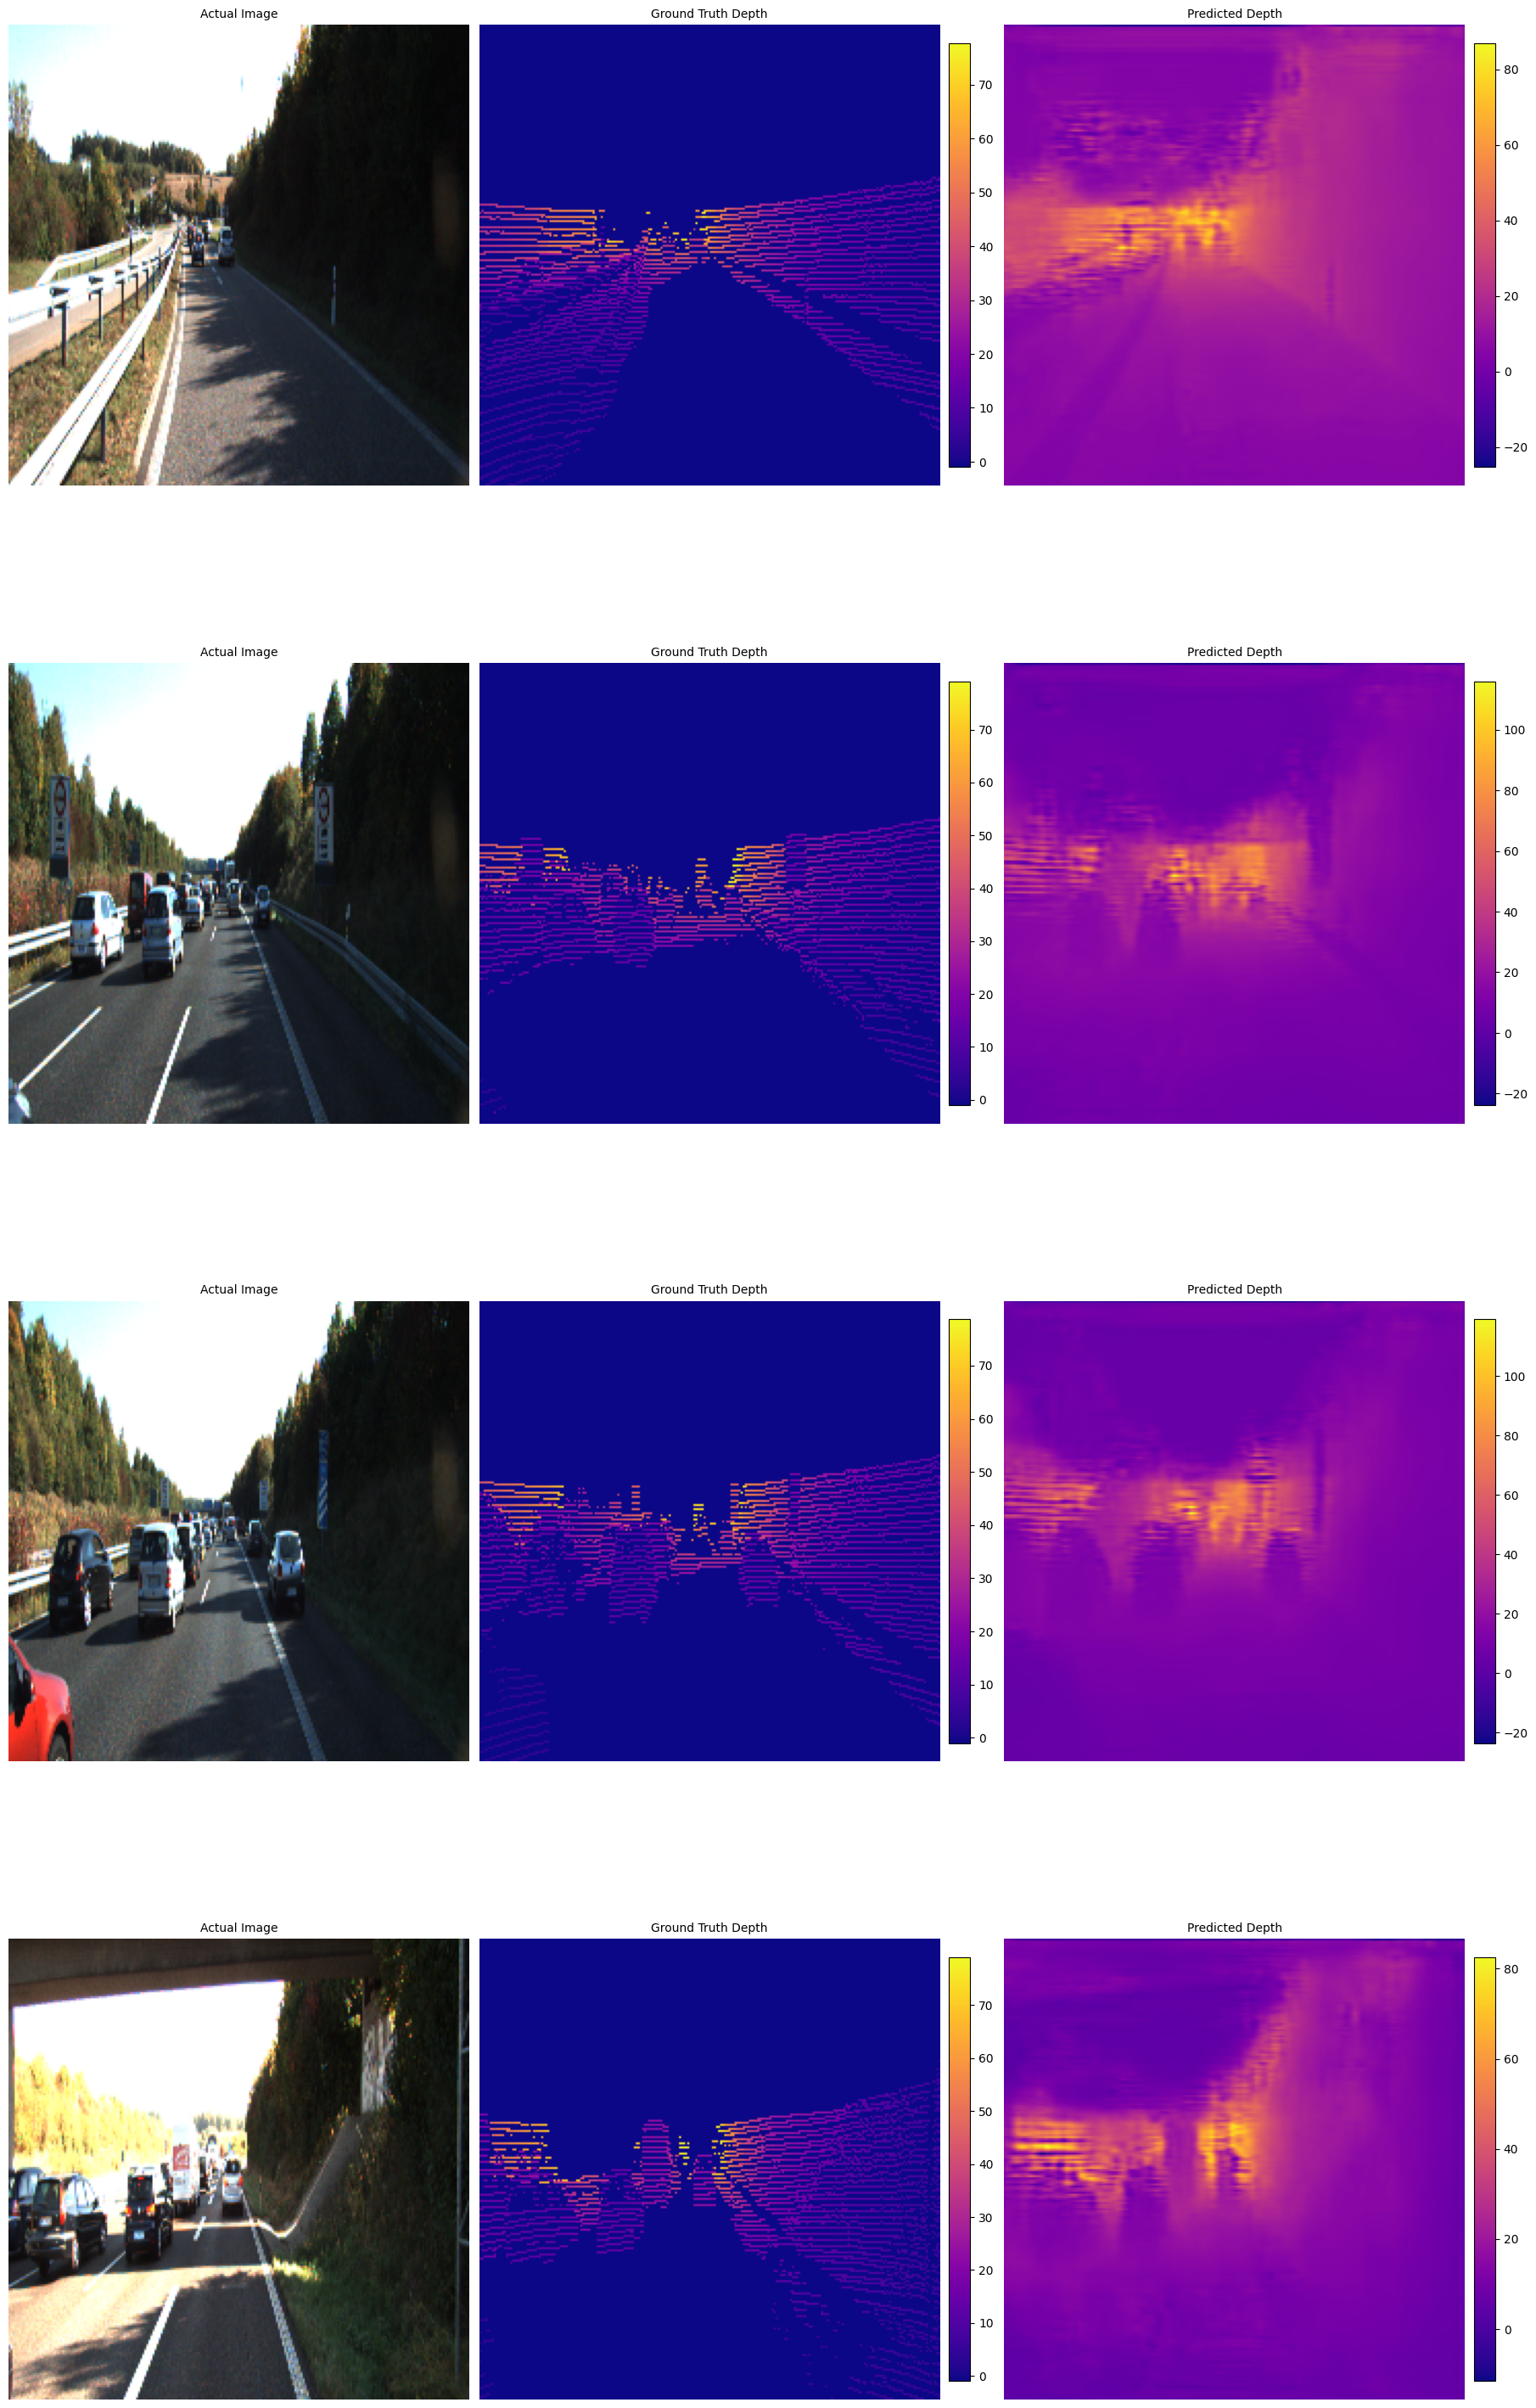

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

num_samples = 4

# Lists to store the results.
actual_images = []
gt_depths = []
pred_depths = []
images_with_boxes = []

model.eval()  # Ensure model is in evaluation mode.
sample_count = 0

# Iterate over the dataloader until we collect num_samples samples.
for sample in dataloader:
    left_image_batch, _, uvz_points_batch = sample

    # Process the first image in the batch.
    img = left_image_batch[0]
    if isinstance(img, torch.Tensor):
        img = img.cpu().numpy()
        if img.shape[0] == 3:
            img = img.transpose(1, 2, 0)  # Convert from CHW to HWC

    # Resize the image to 224x224.
    img_resized = cv2.resize(img, (224, 224))

    # Prepare model input.
    input_tensor = transform(img_resized).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)

    with torch.no_grad():
        pred_bbox, pred_depth = model(input_tensor)
    pred_depth_np = pred_depth.squeeze().cpu().numpy()  # (224, 224)
    pred_bbox_np = pred_bbox.squeeze().cpu().numpy()      # shape: (4,) normalized [0,1]

    # Process ground truth depth.
    uvz_points = uvz_points_batch[0]
    if isinstance(uvz_points, torch.Tensor):
        uvz_points = uvz_points.cpu().numpy()

    # Use original image dimensions (from original image "img") to compute scale.
    orig_h, orig_w, _ = img.shape
    scale_x = 224 / orig_w
    scale_y = 224 / orig_h
    uvz_points_scaled = uvz_points.copy()
    uvz_points_scaled[:, 0] *= scale_x  # Scale u coordinate.
    uvz_points_scaled[:, 1] *= scale_y  # Scale v coordinate.

    gt_depth = uvz_to_matrix(uvz_points_scaled, (224, 224))

    # Compute ground truth bounding box (normalized) using the helper.
    gt_bbox_np = get_bbox_from_uvz(uvz_points_scaled, image_shape=(224, 224))

    # Convert normalized bounding boxes to pixel coordinates for a 224x224 image.
    gt_bbox_px = np.array([
        int(gt_bbox_np[0] * 224),
        int(gt_bbox_np[1] * 224),
        int(gt_bbox_np[2] * 224),
        int(gt_bbox_np[3] * 224)
    ], dtype=np.int32)
    pred_bbox_px = np.array([
        int(pred_bbox_np[0] * 224),
        int(pred_bbox_np[1] * 224),
        int(pred_bbox_np[2] * 224),
        int(pred_bbox_np[3] * 224)
    ], dtype=np.int32)

    # Draw bounding boxes on a copy of the actual image.
    img_with_boxes = img_resized.copy()
    # Draw ground truth bbox in green.
    cv2.rectangle(img_with_boxes,
                  (gt_bbox_px[0], gt_bbox_px[1]),
                  (gt_bbox_px[0] + gt_bbox_px[2], gt_bbox_px[1] + gt_bbox_px[3]),
                  (0, 255, 0), 2)
    # Draw predicted bbox in red.
    cv2.rectangle(img_with_boxes,
                  (pred_bbox_px[0], pred_bbox_px[1]),
                  (pred_bbox_px[0] + pred_bbox_px[2], pred_bbox_px[1] + pred_bbox_px[3]),
                  (255, 0, 0), 2)

    # Append results.
    actual_images.append(img_resized)
    gt_depths.append(gt_depth)
    pred_depths.append(pred_depth_np)
    images_with_boxes.append(img_with_boxes)

    sample_count += 1
    if sample_count >= num_samples:
        break

# Create a figure with 10 rows and 3 columns.
fig, axes = plt.subplots(num_samples, 3, figsize=(18, 30), constrained_layout=True)

for i in range(num_samples):
    # Column 1: Actual Image.
    axes[i, 0].imshow(actual_images[i])
    axes[i, 0].set_title("Actual Image", fontsize=10)
    axes[i, 0].axis("off")

    # Column 2: Ground Truth Depth Map.
    im_gt = axes[i, 1].imshow(gt_depths[i], cmap='plasma')
    axes[i, 1].set_title("Ground Truth Depth", fontsize=10)
    axes[i, 1].axis("off")
    fig.colorbar(im_gt, ax=axes[i, 1], fraction=0.046, pad=0.02)

    # Column 3: Predicted Depth Map.
    im_pred = axes[i, 2].imshow(pred_depths[i], cmap='plasma')
    axes[i, 2].set_title("Predicted Depth", fontsize=10)
    axes[i, 2].axis("off")
    fig.colorbar(im_pred, ax=axes[i, 2], fraction=0.046, pad=0.02)

plt.show()
